In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import gc

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [2]:
def read_random_sample(path, frac=0.05, seed=42):
    """
    Randomly samples rows while reading a large CSV.
    Keeps header row.
    """
    np.random.seed(seed)
    
    return pd.read_csv(
        path,
        usecols=[
            "event_time",
            "event_type",
            "product_id",
            "category_id",
            "category_code",
            "brand",
            "price",
            "user_id",
            "user_session"
        ],
        skiprows=lambda i: i > 0 and np.random.rand() > frac
    )

In [3]:
df_oct = read_random_sample('/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv', frac=0.04, seed=42)
df_nov = read_random_sample('/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv', frac=0.04, seed=43)

df = pd.concat([df_oct, df_nov], ignore_index=True)

del df_oct, df_nov
gc.collect()

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:11 UTC,view,2900536,2053013554776244595,appliances.kitchen.microwave,elenberg,51.46,555158050,b5bdd0b3-4ca2-4c55-939e-9ce44bb50abd
1,2019-10-01 00:00:34 UTC,view,26200591,2053013563693335403,NaN,NaN,203.35,555447748,b50d1ae8-1948-4517-8460-09b7601ceef6
2,2019-10-01 00:01:00 UTC,view,3701062,2053013565983425517,appliances.environment.vacuum,gorenje,90.07,515342595,0e30e1c0-4d3e-4e1a-90e3-ab93b5f5c1a2
3,2019-10-01 00:01:27 UTC,view,10800076,2053013554994348409,NaN,redmond,54.03,539194858,5fe9d0a0-0de6-47de-a55a-eae9f89475cd
4,2019-10-01 00:01:28 UTC,view,3900815,2053013552326770905,appliances.environment.water_heater,ariston,133.82,531646433,f19e3ef4-a4c3-48b3-8a2b-9533fcf5d727


In [4]:
df["event_time"] = pd.to_datetime(df["event_time"], utc=True)
df["event_date"] = df["event_time"].dt.date
df["event_hour"] = df["event_time"].dt.hour

df["event_type"] = df["event_type"].astype("category")
df["category_code"] = df["category_code"].fillna("unknown").astype("category")
df["brand"] = df["brand"].fillna("unknown").astype("category")

df["product_id"] = df["product_id"].astype("int32")
df["category_id"] = df["category_id"].astype("int64")
df["user_id"] = df["user_id"].astype("int64")

df = df.dropna(subset=["user_session"])
df = df[df["price"] >= 0]

df = df.sort_values(["user_id", "event_time"])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4397973 entries, 2349140 to 4397971
Data columns (total 11 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[ns, UTC]
 1   event_type     category           
 2   product_id     int32              
 3   category_id    int64              
 4   category_code  category           
 5   brand          category           
 6   price          float64            
 7   user_id        int64              
 8   user_session   object             
 9   event_date     object             
 10  event_hour     int32              
dtypes: category(3), datetime64[ns, UTC](1), float64(1), int32(2), int64(2), object(2)
memory usage: 289.6+ MB


In [5]:
print("Rows:", df.shape[0])
print("Users:", df["user_id"].nunique())
print("Sessions:", df["user_session"].nunique())
print("Products:", df["product_id"].nunique())
print("Dates:", df["event_time"].min(), "—", df["event_time"].max())

df["event_type"].value_counts(normalize=True)

Rows: 4397973
Users: 1732300
Sessions: 3508537
Products: 144541
Dates: 2019-10-01 00:00:11+00:00 — 2019-11-30 23:59:57+00:00


event_type
view        0.949006
cart        0.036011
purchase    0.014983
Name: proportion, dtype: float64

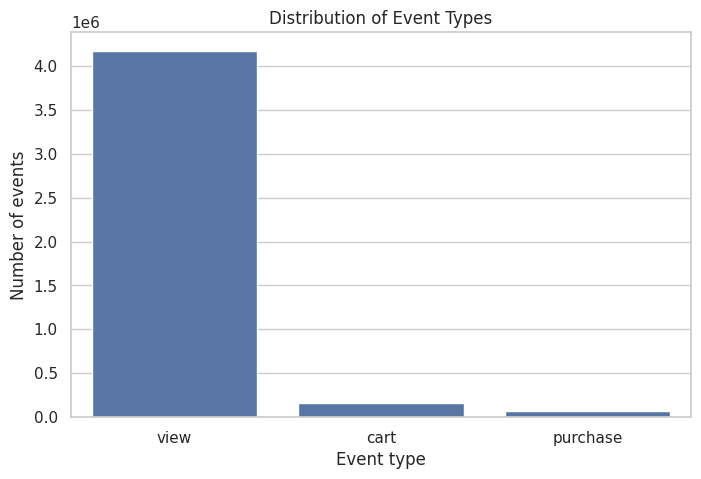

In [29]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="event_type", order=df["event_type"].value_counts().index)
plt.title("Distribution of Event Types")
plt.xlabel("Event type")
plt.ylabel("Number of events")
plt.show()

## Большинство пользователей просто смотрят, лишь малая часть доходит до покупки

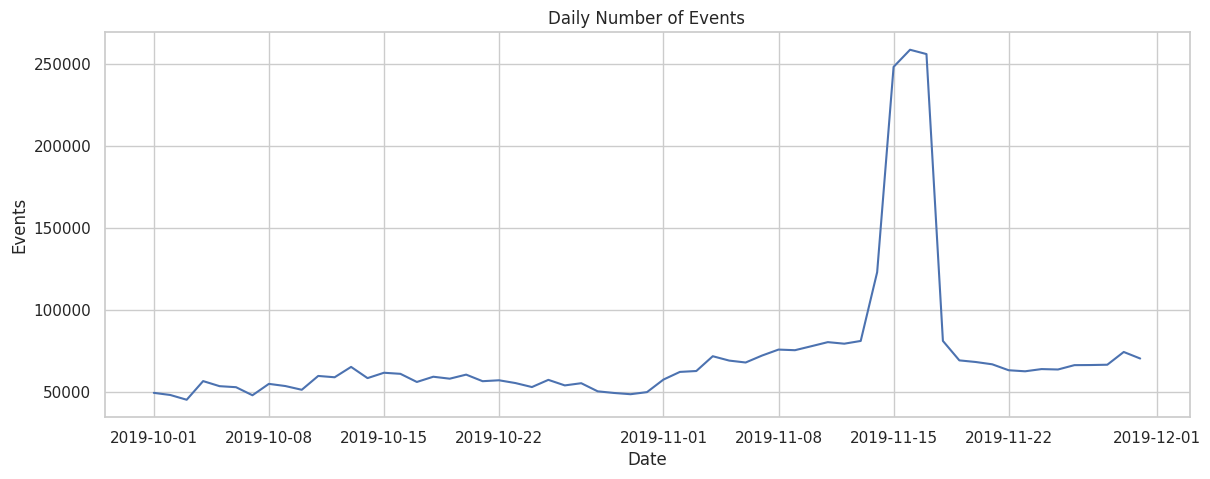

In [31]:
daily_events = df.groupby("event_date").size()

plt.figure(figsize=(14, 5))
daily_events.plot()
plt.title("Daily Number of Events")
plt.xlabel("Date")
plt.ylabel("Events")
plt.show()

## Стабильный уровень активности, резкий пик в середине ноября, наверное ажиотаж вокруг 11.11. 

/tmp/ipykernel_57/478392909.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["event_date", "event_type"])


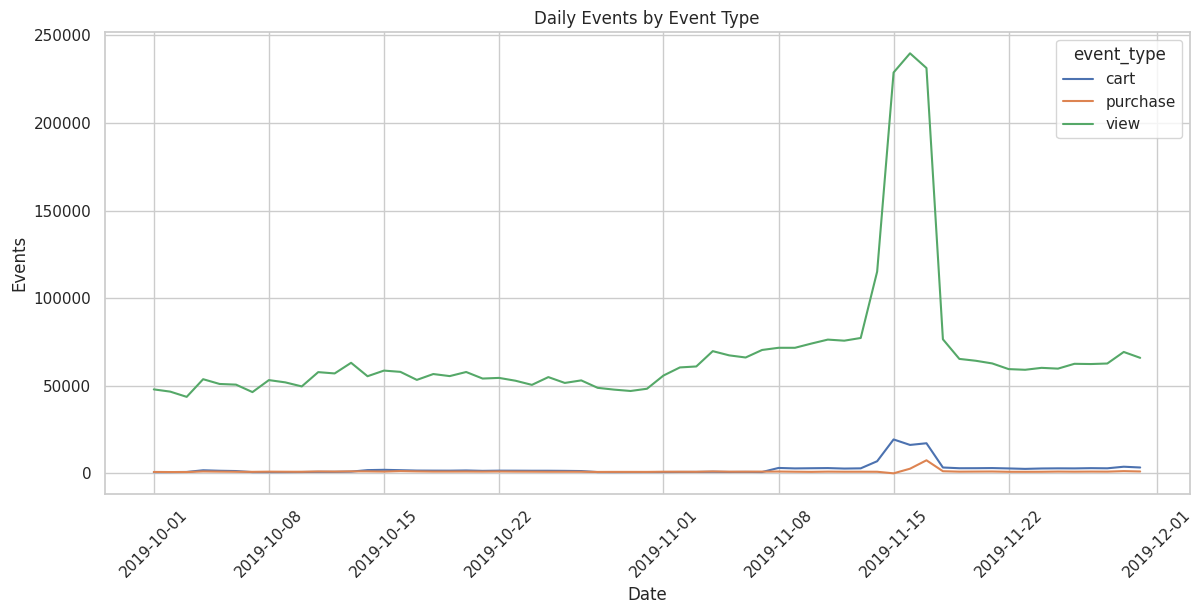

In [32]:
daily_event_types = (
    df.groupby(["event_date", "event_type"])
      .size()
      .reset_index(name="events")
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=daily_event_types,
    x="event_date",
    y="events",
    hue="event_type"
)
plt.title("Daily Events by Event Type")
plt.xlabel("Date")
plt.ylabel("Events")
plt.xticks(rotation=45)
plt.show()

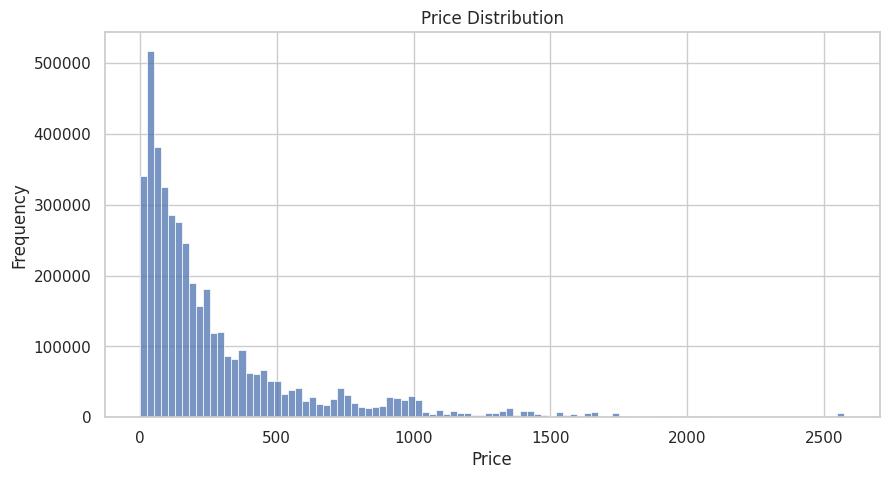

In [33]:
plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=100)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

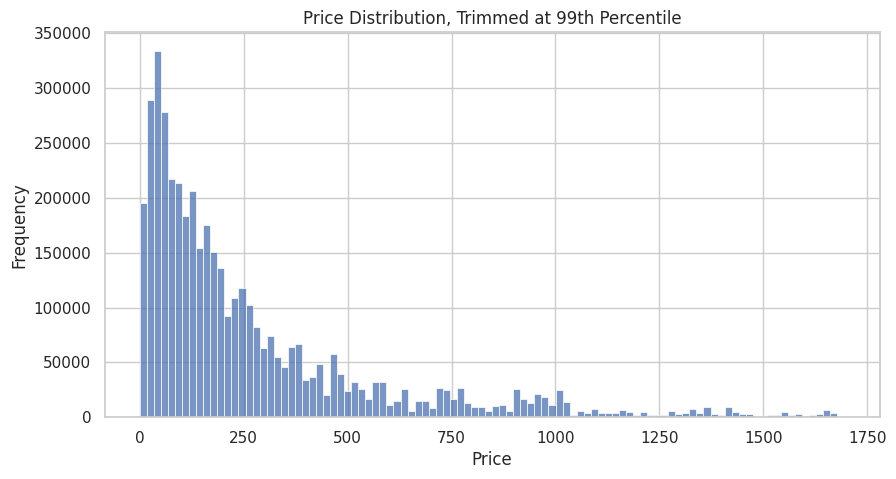

Price p99: 1695.41


In [34]:
price_p99 = df["price"].quantile(0.99)

plt.figure(figsize=(10, 5))
sns.histplot(df[df["price"] <= price_p99]["price"], bins=100)
plt.title("Price Distribution, Trimmed at 99th Percentile")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

print("Price p99:", price_p99)

## Сильный перекос вправо, много дешёвых товаров, немного очень дорогих

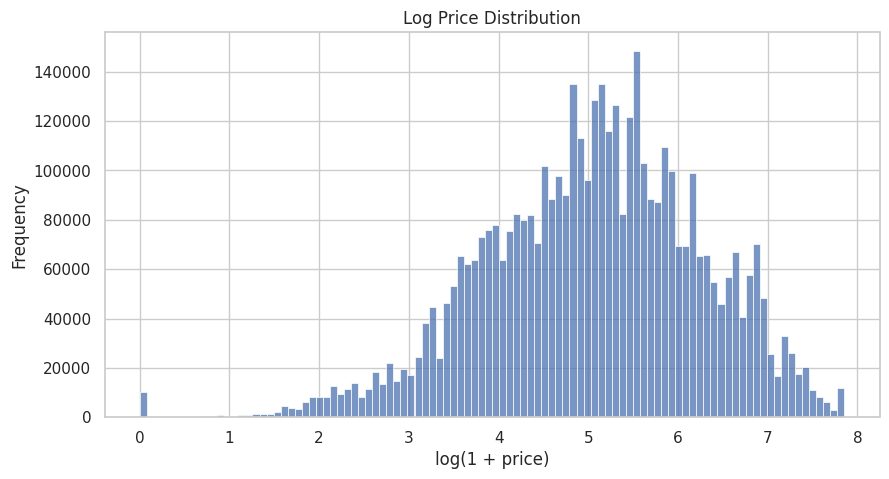

In [35]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df["price"]), bins=100)
plt.title("Log Price Distribution")
plt.xlabel("log(1 + price)")
plt.ylabel("Frequency")
plt.show()

## Распределение становится почти нормальным

In [6]:
df["is_view"] = (df["event_type"] == "view").astype("int8")
df["is_cart"] = (df["event_type"] == "cart").astype("int8")
df["is_remove"] = (df["event_type"] == "remove_from_cart").astype("int8")
df["is_purchase"] = (df["event_type"] == "purchase").astype("int8")

df["purchase_revenue"] = np.where(df["event_type"] == "purchase", df["price"], 0)

In [7]:
user_df = (
    df.groupby("user_id")
      .agg(
          first_event_time=("event_time", "min"),
          last_event_time=("event_time", "max"),
          active_days=("event_date", "nunique"),
          sessions=("user_session", "nunique"),
          events=("event_type", "size"),
          views=("is_view", "sum"),
          carts=("is_cart", "sum"),
          removes=("is_remove", "sum"),
          purchases=("is_purchase", "sum"),
          revenue=("purchase_revenue", "sum"),
          avg_viewed_price=("price", "mean"),
          unique_products=("product_id", "nunique"),
          unique_categories=("category_code", "nunique")
      )
      .reset_index()
)

user_df["has_cart"] = (user_df["carts"] > 0).astype("int8")
user_df["has_purchase"] = (user_df["purchases"] > 0).astype("int8")

user_df["cart_rate"] = user_df["carts"] / user_df["views"].replace(0, np.nan)
user_df["purchase_rate"] = user_df["purchases"] / user_df["views"].replace(0, np.nan)
user_df["cart_to_purchase_rate"] = user_df["purchases"] / user_df["carts"].replace(0, np.nan)

user_df["revenue_per_session"] = user_df["revenue"] / user_df["sessions"].replace(0, np.nan)
user_df["events_per_session"] = user_df["events"] / user_df["sessions"].replace(0, np.nan)
user_df["views_per_session"] = user_df["views"] / user_df["sessions"].replace(0, np.nan)

user_df["lifetime_days"] = (
    user_df["last_event_time"] - user_df["first_event_time"]
).dt.total_seconds() / 86400

user_df.head()

,user_id,first_event_time,last_event_time,active_days,sessions,events,views,carts,removes,purchases,revenue,avg_viewed_price,unique_products,unique_categories,has_cart,has_purchase,cart_rate,purchase_rate,cart_to_purchase_rate,revenue_per_session,events_per_session,views_per_session,lifetime_days
0,49484535,2019-11-10 11:54:22+00:00,2019-11-10 11:54:22+00:00,1,1,1,1,0,0,0,0.0,55.34,1,1,0,0,0.0,0.0,NaN,0.0,1.0,1.0,0.0
1,62336140,2019-11-08 15:56:08+00:00,2019-11-08 15:56:08+00:00,1,1,1,1,0,0,0,0.0,177.35,1,1,0,0,0.0,0.0,NaN,0.0,1.0,1.0,0.0
2,82678143,2019-11-21 03:19:42+00:00,2019-11-21 03:19:42+00:00,1,1,1,1,0,0,0,0.0,24.97,1,1,0,0,0.0,0.0,NaN,0.0,1.0,1.0,0.0
3,91389712,2019-11-19 13:31:59+00:00,2019-11-19 13:31:59+00:00,1,1,1,1,0,0,0,0.0,84.94,1,1,0,0,0.0,0.0,NaN,0.0,1.0,1.0,0.0
4,92346331,2019-11-26 11:14:02+00:00,2019-11-26 11:14:02+00:00,1,1,1,1,0,0,0,0.0,141.57,1,1,0,0,0.0,0.0,NaN,0.0,1.0,1.0,0.0


In [8]:
print("Users:", user_df.shape[0])
print("Share with cart:", user_df["has_cart"].mean())
print("Share with purchase:", user_df["has_purchase"].mean())
print("Average revenue per user:", user_df["revenue"].mean())
print("Median revenue per user:", user_df["revenue"].median())

user_df.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

Users: 1732300
Share with cart: 0.07685851180511459
Share with purchase: 0.03369797379206835
Average revenue per user: 11.529499676730367
Median revenue per user: 0.0


,user_id,active_days,sessions,events,views,carts,removes,purchases,revenue,avg_viewed_price,unique_products,unique_categories,has_cart,has_purchase,cart_rate,purchase_rate,cart_to_purchase_rate,revenue_per_session,events_per_session,views_per_session,lifetime_days
count,1.732300e+06,1.732300e+06,1.732300e+06,1.732300e+06,1.732300e+06,1.732300e+06,1732300.0,1.732300e+06,1.732300e+06,1.732300e+06,1.732300e+06,1.732300e+06,1.732300e+06,1.732300e+06,1.680715e+06,1.680715e+06,133142.000000,1.732300e+06,1.732300e+06,1.732300e+06,1.732300e+06
mean,5.409593e+08,1.779639e+00,2.025369e+00,2.538806e+00,2.409341e+00,9.142585e-02,0.0,3.803902e-02,1.152950e+01,3.024514e+02,2.360643e+00,1.486392e+00,7.685851e-02,3.369797e-02,3.100288e-02,1.289014e-02,0.101736,5.643215e+00,1.205327e+00,1.142401e+00,7.228565e+00
std,2.225854e+07,1.637314e+00,2.485389e+00,3.530453e+00,3.436114e+00,3.591373e-01,0.0,2.258716e-01,1.053731e+02,3.318377e+02,3.015705e+00,1.005442e+00,2.663669e-01,1.804507e-01,1.675892e-01,1.033024e-01,0.355149,5.483948e+01,5.045043e-01,5.372906e-01,1.364738e+01
min,4.948454e+07,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.416836e+08,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,1.899700e+02,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
75%,5.607930e+08,2.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,3.807670e+02,3.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,1.166667e+00,1.000000e+00,7.702784e+00
90%,5.705447e+08,3.000000e+00,4.000000e+00,5.000000e+00,5.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,7.336100e+02,5.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,2.000000e+00,2.000000e+00,3.084610e+01
95%,5.733264e+08,5.000000e+00,6.000000e+00,8.000000e+00,7.000000e+00,1.000000e+00,0.0,0.000000e+00,0.000000e+00,9.778900e+02,7.000000e+00,3.000000e+00,1.000000e+00,0.000000e+00,1.250000e-01,0.000000e+00,1.000000,0.000000e+00,2.000000e+00,2.000000e+00,4.121274e+01
99%,5.779588e+08,9.000000e+00,1.100000e+01,1.600000e+01,1.500000e+01,2.000000e+00,0.0,1.000000e+00,3.346000e+02,1.619347e+03,1.400000e+01,6.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.000000e-01,2.000000,1.635423e+02,3.000000e+00,3.000000e+00,5.307487e+01
max,5.799695e+08,6.000000e+01,9.500000e+02,9.520000e+02,9.520000e+02,3.400000e+01,0.0,2.700000e+01,1.417113e+04,2.574070e+03,7.160000e+02,2.700000e+01,1.000000e+00,1.000000e+00,1.500000e+01,6.000000e+00,9.000000,3.184410e+03,1.700000e+02,1.700000e+02,6.076995e+01


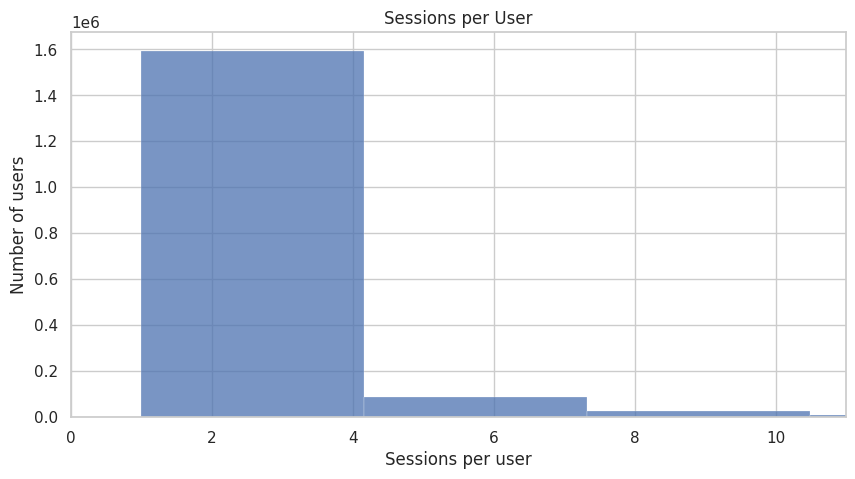

In [62]:
plt.figure(figsize=(10, 5))
sns.histplot(user_df["sessions"], bins=300)
plt.xlim(0, user_df["sessions"].quantile(0.99))
plt.title("Sessions per User")
plt.xlabel("Sessions per user")
plt.ylabel("Number of users")
plt.show()

## Большинство пользователей имеют 1–4 сессии, длинный хвост активных пользователей

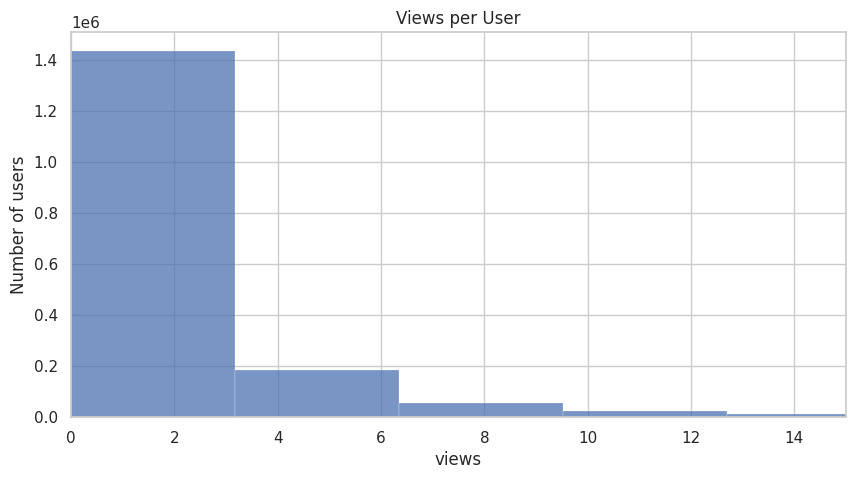

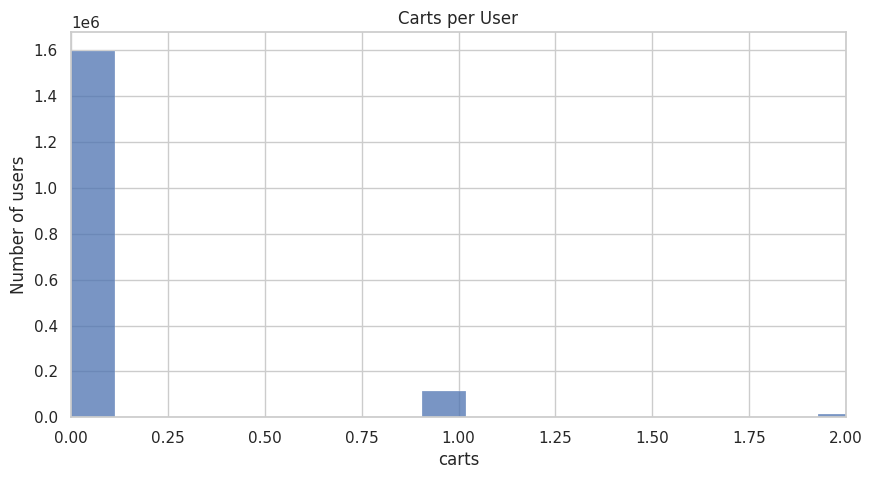

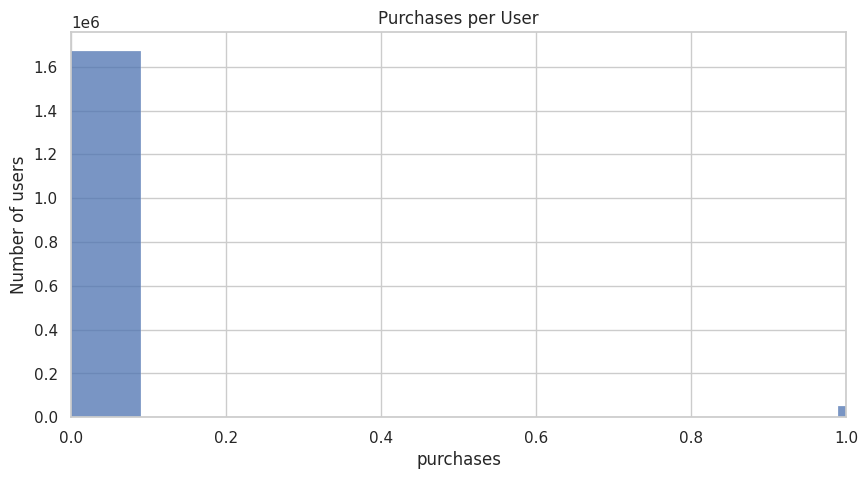

In [63]:
for col in ["views", "carts", "purchases"]:
    plt.figure(figsize=(10, 5))
    sns.histplot(user_df[col], bins=300)
    plt.xlim(0, user_df[col].quantile(0.99))
    plt.title(f"{col.capitalize()} per User")
    plt.xlabel(col)
    plt.ylabel("Number of users")
    plt.show()

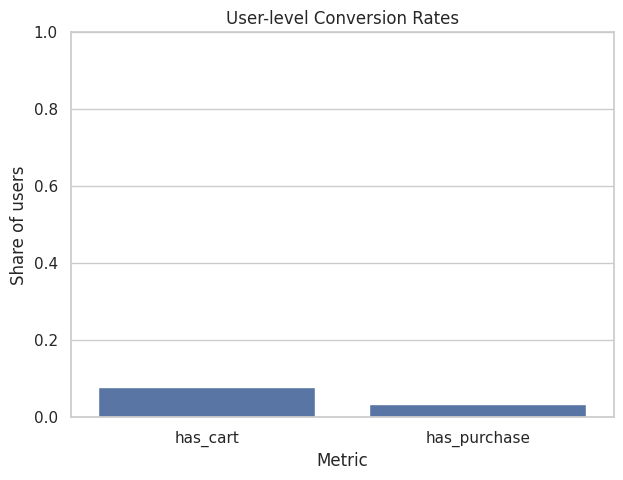

,metric,value
0,has_cart,0.076859
1,has_purchase,0.033698


In [52]:
conversion_summary = pd.DataFrame({
    "metric": ["has_cart", "has_purchase"],
    "value": [
        user_df["has_cart"].mean(),
        user_df["has_purchase"].mean()
    ]
})

plt.figure(figsize=(7, 5))
sns.barplot(data=conversion_summary, x="metric", y="value")
plt.title("User-level Conversion Rates")
plt.xlabel("Metric")
plt.ylabel("Share of users")
plt.ylim(0, 1)
plt.show()

conversion_summary

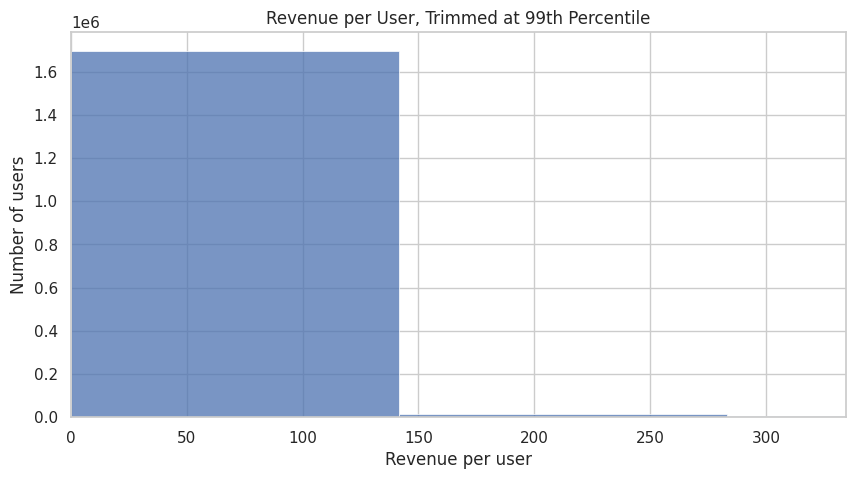

In [73]:
plt.figure(figsize=(10, 5))
sns.histplot(user_df["revenue"], bins=100)
plt.xlim(0, user_df["revenue"].quantile(0.99))
plt.title("Revenue per User, Trimmed at 99th Percentile")
plt.xlabel("Revenue per user")
plt.ylabel("Number of users")
plt.show()

## Огромная масса около 0, почти все пользователи ничего не покупают

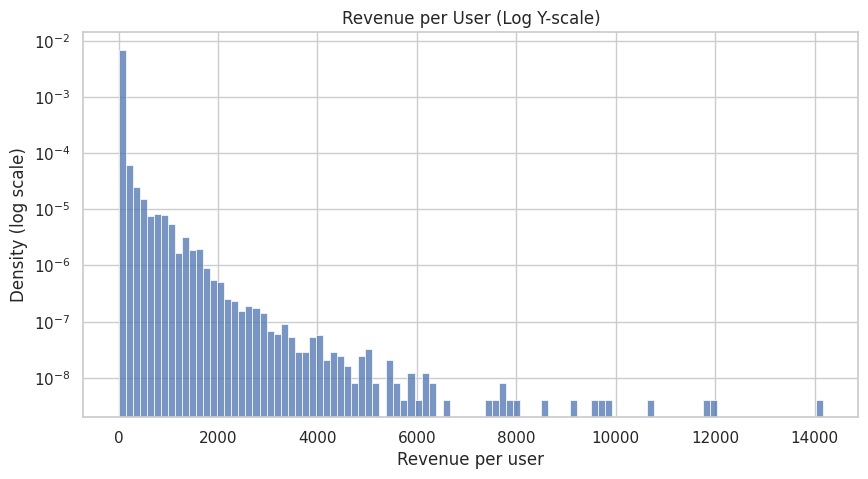

In [75]:
plt.figure(figsize=(10, 5))

sns.histplot(
    user_df["revenue"],
    bins=100,
    stat="density"
)

plt.yscale("log")

plt.title("Revenue per User (Log Y-scale)")
plt.xlabel("Revenue per user")
plt.ylabel("Density (log scale)")

plt.show()

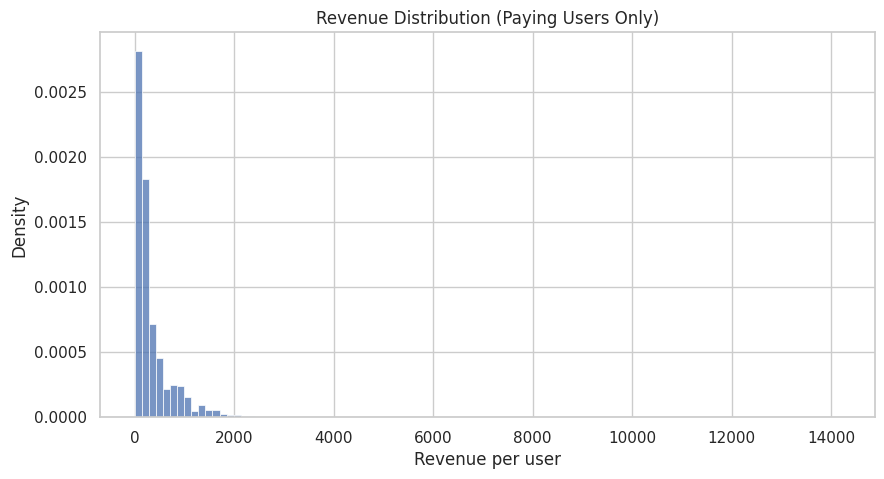

In [74]:
paying_users = user_df[user_df["revenue"] > 0]["revenue"]

plt.figure(figsize=(10, 5))

sns.histplot(
    paying_users,
    bins=100,
    stat="density"
)

plt.title("Revenue Distribution (Paying Users Only)")
plt.xlabel("Revenue per user")
plt.ylabel("Density")

plt.show()

## Продуктовая идея: новая рекомендательная система лучше подбирает товары и повышает вероятность добавления товара в корзину.

## H0: новая рекомендация не меняет поведение пользователей.
## H1: новая рекомендация увеличивает добавления в корзину и приводит к росту покупок / revenue.

In [9]:
np.random.seed(42)

ab_df = user_df.copy()

ab_df = ab_df.replace([np.inf, -np.inf], np.nan)

ab_df["views"] = ab_df["views"].fillna(0).astype(int)
ab_df["carts"] = ab_df["carts"].fillna(0).astype(int)
ab_df["purchases"] = ab_df["purchases"].fillna(0).astype(int)
ab_df["revenue"] = ab_df["revenue"].fillna(0)

ab_df["has_cart"] = (ab_df["carts"] > 0).astype(int)
ab_df["has_purchase"] = (ab_df["purchases"] > 0).astype(int)

# Рандомизация
ab_df["group"] = np.random.choice(
    ["control", "treatment"],
    size=len(ab_df),
    p=[0.5, 0.5]
)

## Фича влияет на добавление в корзину. Покупки и revenue не пересоздаются с нуля. Мы добавляем только инкрементальный эффект treatment-группе

In [10]:
# Копируем baseline-метрики
ab_df["views_exp"] = ab_df["views"].copy()
ab_df["carts_exp"] = ab_df["carts"].copy()
ab_df["purchases_exp"] = ab_df["purchases"].copy()
ab_df["revenue_exp"] = ab_df["revenue"].copy()

ab_df["has_cart_exp"] = ab_df["has_cart"].copy()
ab_df["has_purchase_exp"] = ab_df["has_purchase"].copy()

treatment_mask = ab_df["group"] == "treatment"

In [11]:
# Фича работает только у части пользователей
affected_mask = treatment_mask & (np.random.rand(len(ab_df)) < 0.30)

# Эффект сильнее проявляется у пользователей, у которых были просмотры
eligible_mask = affected_mask & (ab_df["views_exp"] > 0)

## Добавляем инкрементальные корзины

In [12]:
# Вероятность получить дополнительный cart
# больше у пользователей с большим количеством views
cart_add_prob = np.minimum(
    0.02 + 0.01 * np.log1p(ab_df["views_exp"]),
    0.20
)

add_cart = np.random.binomial(
    n=1,
    p=cart_add_prob
)

add_cart_mask = eligible_mask & (add_cart == 1)

ab_df.loc[add_cart_mask, "carts_exp"] += 1
ab_df.loc[ab_df["carts_exp"] > 0, "has_cart_exp"] = 1

## Прокидываем эффект дальше в покупки, покупка появляется только у части пользователей с новым cart.

In [13]:
# Инкрементальная вероятность покупки после дополнительной корзины
incremental_purchase_prob = 0.08

new_purchase = np.random.binomial(
    n=1,
    p=incremental_purchase_prob,
    size=len(ab_df)
)

new_purchase_mask = (
    add_cart_mask
    & (ab_df["has_purchase_exp"] == 0)
    & (new_purchase == 1)
)

ab_df.loc[new_purchase_mask, "purchases_exp"] += 1
ab_df.loc[new_purchase_mask, "has_purchase_exp"] = 1

## Добавляем revenue только для новых покупок

In [14]:
# Берём реальные чеки из baseline-покупок
paying_revenue = ab_df.loc[ab_df["revenue"] > 0, "revenue"]

# Защита от экстремальных выбросов
revenue_p01 = paying_revenue.quantile(0.01)
revenue_p99 = paying_revenue.quantile(0.99)

paying_revenue_clean = paying_revenue.clip(revenue_p01, revenue_p99)

# Для новых покупателей генерируем чек из реального распределения
new_revenue = np.random.choice(
    paying_revenue_clean.values,
    size=new_purchase_mask.sum(),
    replace=True
)

ab_df.loc[new_purchase_mask, "revenue_exp"] += new_revenue

In [15]:
ab_df["cart_rate_exp"] = (
    ab_df["carts_exp"] / ab_df["views_exp"].replace(0, np.nan)
).fillna(0)

ab_df["purchase_rate_exp"] = (
    ab_df["purchases_exp"] / ab_df["views_exp"].replace(0, np.nan)
).fillna(0)

metrics = ab_df.groupby("group").agg(
    users=("user_id", "count"),
    revenue_per_user=("revenue_exp", "mean"),
    purchase_conversion=("has_purchase_exp", "mean"),
    cart_conversion=("has_cart_exp", "mean"),
    cart_rate=("cart_rate_exp", "mean"),
    purchase_rate=("purchase_rate_exp", "mean"),
    sessions_per_user=("sessions", "mean")
)

metrics

,users,revenue_per_user,purchase_conversion,cart_conversion,cart_rate,purchase_rate,sessions_per_user
group,,,,,,,
control,866725,11.462110,0.033487,0.077196,0.030152,0.012316,2.028154
treatment,865575,11.823168,0.034622,0.084878,0.035758,0.013159,2.022579


### В эксперименте участвовало примерно одинаковое количество пользователей в контрольной и тестовой группах, что говорит о корректной рандомизации.

### Средний Revenue per User вырос с 11.46 до 11.82 (+3.15%), что является положительным сигналом для бизнеса.

### Конверсия в покупку увеличилась с 3.35% до 3.46% (+3.39%), что означает, что больше пользователей стали совершать покупки.

### Конверсия в корзину выросла с 7.72% до 8.49% (+9.95%), а cart rate (количество добавлений в корзину на просмотр) увеличился на 18.6%.

### При этом среднее количество сессий на пользователя осталось стабильным, что говорит о том, что эффект не связан с изменением активности пользователей, а именно с изменением поведения внутри сессий.

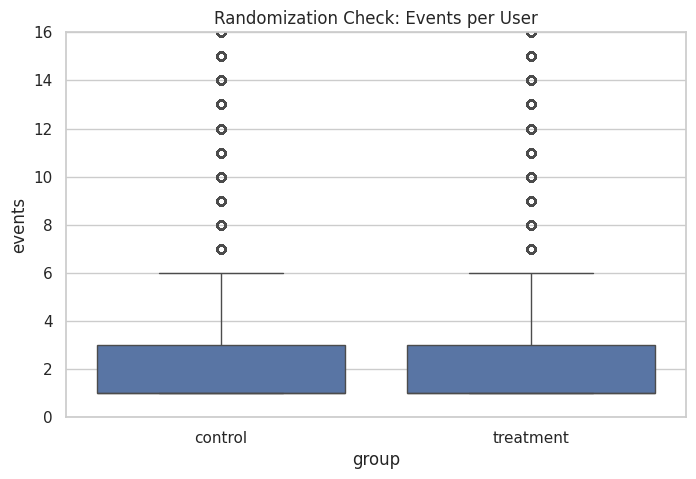

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=ab_df,
    x="group",
    y="events"
)
plt.ylim(0, ab_df["events"].quantile(0.99))
plt.title("Randomization Check: Events per User")
plt.show()

In [17]:
def bootstrap_mean_diff(data, metric, group_col="group", n_bootstrap=5000, seed=42):
    np.random.seed(seed)
    
    control = data[data[group_col] == "control"][metric].values
    treatment = data[data[group_col] == "treatment"][metric].values
    
    boot_diffs = []
    
    for _ in range(n_bootstrap):
        control_sample = np.random.choice(control, size=len(control), replace=True)
        treatment_sample = np.random.choice(treatment, size=len(treatment), replace=True)
        
        boot_diffs.append(treatment_sample.mean() - control_sample.mean())
    
    boot_diffs = np.array(boot_diffs)
    
    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
    p_value = 2 * min(
        np.mean(boot_diffs <= 0),
        np.mean(boot_diffs >= 0)
    )
    
    return {
        "control_mean": control.mean(),
        "treatment_mean": treatment.mean(),
        "absolute_diff": treatment.mean() - control.mean(),
        "relative_diff_%": (treatment.mean() - control.mean()) / control.mean() * 100,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "p_value": p_value
    }


bootstrap_rpu = bootstrap_mean_diff(ab_df, "revenue_exp")
bootstrap_rpu

{'control_mean': np.float64(11.462109584931785),
 'treatment_mean': np.float64(11.823168215810297),
 'absolute_diff': np.float64(0.361058630878512),
 'relative_diff_%': np.float64(3.150019010053469),
 'ci_low': np.float64(0.05423348461877544),
 'ci_high': np.float64(0.6809742634802347),
 'p_value': np.float64(0.0236)}

### Для анализа основной метрики Revenue per User был использован bootstrap, так как распределение выручки сильно скошено и содержит большое количество нулей.

### Средний Revenue per User в treatment группе составил 11.82 против 11.46 в control, что даёт абсолютный прирост +0.36 и относительный +3.15%.

### 95% доверительный интервал bootstrap: [0.05 ; 0.68], полностью лежит выше нуля. Это означает, что эффект статистически значим.

### p-value = 0.0236, что меньше 0.05, поэтому нулевая гипотеза отвергается.

### Таким образом, можно заключить, что новая фича приводит к статистически значимому росту выручки на пользователя.

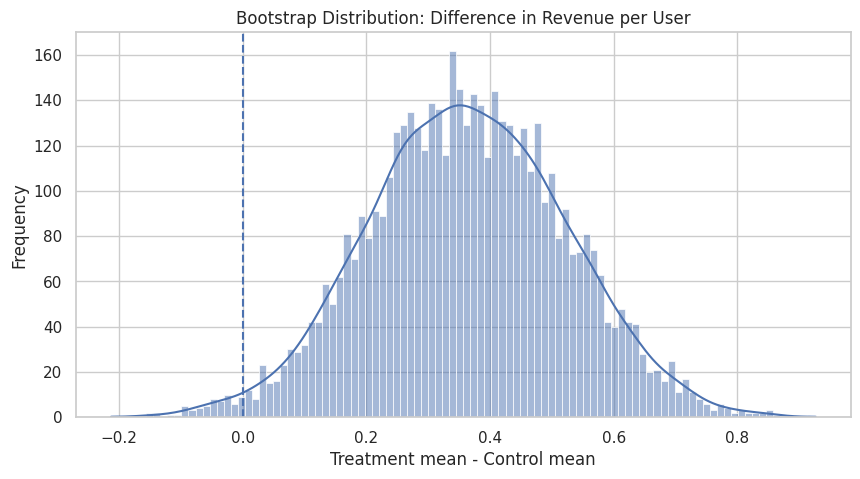

In [18]:
control = ab_df[ab_df["group"] == "control"]["revenue_exp"].values
treatment = ab_df[ab_df["group"] == "treatment"]["revenue_exp"].values

boot_diffs = []

for _ in range(5000):
    c = np.random.choice(control, size=len(control), replace=True)
    t = np.random.choice(treatment, size=len(treatment), replace=True)
    boot_diffs.append(t.mean() - c.mean())

plt.figure(figsize=(10, 5))
sns.histplot(boot_diffs, bins=100, kde=True)
plt.axvline(0, linestyle="--")
plt.title("Bootstrap Distribution: Difference in Revenue per User")
plt.xlabel("Treatment mean - Control mean")
plt.ylabel("Frequency")
plt.show()

### Распределение bootstrap-разностей (treatment - control) смещено вправо относительно нуля.

### Вертикальная линия на уровне 0 находится левее основной массы распределения, что визуально подтверждает положительный эффект.

### Это означает, что в большинстве bootstrap-выборок средняя выручка в treatment группе выше, чем в control.

### Таким образом, визуальный анализ подтверждает статистический вывод о наличии положительного эффекта.

In [19]:
def proportion_z_test(data, metric, group_col="group"):
    control = data[data[group_col] == "control"][metric]
    treatment = data[data[group_col] == "treatment"][metric]
    
    x1 = treatment.sum()
    n1 = treatment.count()
    
    x0 = control.sum()
    n0 = control.count()
    
    p1 = x1 / n1
    p0 = x0 / n0
    
    p_pool = (x1 + x0) / (n1 + n0)
    
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n0))
    z = (p1 - p0) / se
    
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    
    return {
        "control_rate": p0,
        "treatment_rate": p1,
        "absolute_diff": p1 - p0,
        "relative_diff_%": (p1 - p0) / p0 * 100 if p0 > 0 else np.nan,
        "z_stat": z,
        "p_value": p_value
    }


purchase_test = proportion_z_test(ab_df, "has_purchase_exp")
cart_test = proportion_z_test(ab_df, "has_cart_exp")

purchase_test, cart_test

({'control_rate': np.float64(0.03348697683809743),
  'treatment_rate': np.float64(0.03462207203304162),
  'absolute_diff': np.float64(0.0011350951949441884),
  'relative_diff_%': np.float64(3.3896616001860593),
  'z_stat': np.float64(4.11862591790176),
  'p_value': np.float64(3.8113828668695504e-05)},
 {'control_rate': np.float64(0.07719634255386656),
  'treatment_rate': np.float64(0.08487768246541316),
  'absolute_diff': np.float64(0.0076813399115465975),
  'relative_diff_%': np.float64(9.950393577502279),
  'z_stat': np.float64(18.52396508795385),
  'p_value': np.float64(0.0)})

### Для анализа конверсии в покупку был использован двухвыборочный z-тест для долей, так как метрика является бинарной

### Конверсия выросла с 3.35% до 3.46%, что соответствует относительному росту +3.39%.

### z-статистика = 4.12, p-value ≈ 0.000038, что значительно меньше 0.05.

### Это означает, что рост конверсии статистически значим и не является случайным.

### Таким образом, фича увеличивает вероятность того, что пользователь совершит покупку.

### Аналогично, для cart conversion был использован z-тест для долей.

### Конверсия в добавление в корзину выросла с 7.72% до 8.49%, что соответствует росту +9.95%.

### z-статистика = 18.52, p-value ≈ 0, что указывает на крайне сильную статистическую значимость результата.

### Это означает, что фича существенно влияет на ранний этап воронки — пользователи чаще добавляют товары в корзину.

In [20]:
bootstrap_cart_rate = bootstrap_mean_diff(ab_df, "cart_rate_exp")
bootstrap_cart_rate

{'control_mean': np.float64(0.0301517507965868),
 'treatment_mean': np.float64(0.03575811380962117),
 'absolute_diff': np.float64(0.005606363013034368),
 'relative_diff_%': np.float64(18.59382246442887),
 'ci_low': np.float64(0.0050847966046215455),
 'ci_high': np.float64(0.00612844570033921),
 'p_value': np.float64(0.0)}

### Cart rate был проанализирован с помощью bootstrap, так как это непрерывная и скошенная метрика.

### Среднее значение выросло с 0.03015 до 0.03576, что соответствует росту +18.6%.

### 95% доверительный интервал: [0.00508 ; 0.00613], полностью выше нуля.

### p-value ≈ 0, что подтверждает статистическую значимость эффекта.

### Это означает, что пользователи не только чаще добавляют товары в корзину, но и делают это более интенсивно относительно количества просмотров.

In [21]:
results = pd.DataFrame([
    {
        "metric": "Revenue per User",
        "test": "Bootstrap mean difference",
        **bootstrap_rpu
    },
    {
        "metric": "Purchase Conversion",
        "test": "Two-proportion z-test",
        "control_mean": purchase_test["control_rate"],
        "treatment_mean": purchase_test["treatment_rate"],
        "absolute_diff": purchase_test["absolute_diff"],
        "relative_diff_%": purchase_test["relative_diff_%"],
        "ci_low": np.nan,
        "ci_high": np.nan,
        "p_value": purchase_test["p_value"]
    },
    {
        "metric": "Cart Conversion",
        "test": "Two-proportion z-test",
        "control_mean": cart_test["control_rate"],
        "treatment_mean": cart_test["treatment_rate"],
        "absolute_diff": cart_test["absolute_diff"],
        "relative_diff_%": cart_test["relative_diff_%"],
        "ci_low": np.nan,
        "ci_high": np.nan,
        "p_value": cart_test["p_value"]
    },
    {
        "metric": "Cart Rate",
        "test": "Bootstrap mean difference",
        **bootstrap_cart_rate
    }
])

results

,metric,test,control_mean,treatment_mean,absolute_diff,relative_diff_%,ci_low,ci_high,p_value
0,Revenue per User,Bootstrap mean difference,11.462110,11.823168,0.361059,3.150019,0.054233,0.680974,0.023600
1,Purchase Conversion,Two-proportion z-test,0.033487,0.034622,0.001135,3.389662,NaN,NaN,0.000038
2,Cart Conversion,Two-proportion z-test,0.077196,0.084878,0.007681,9.950394,NaN,NaN,0.000000
3,Cart Rate,Bootstrap mean difference,0.030152,0.035758,0.005606,18.593822,0.005085,0.006128,0.000000


In [22]:
def apply_cuped(df, metric, covariate):
    data = df[[metric, covariate]].dropna()
    
    theta = np.cov(data[metric], data[covariate])[0, 1] / np.var(data[covariate])
    
    adjusted_metric = df[metric] - theta * (df[covariate] - df[covariate].mean())
    
    return adjusted_metric, theta


ab_df["revenue_cuped"], theta_revenue = apply_cuped(
    ab_df,
    metric="revenue_exp",
    covariate="views"
)

theta_revenue

np.float64(1.4317482519419185)

In [23]:
bootstrap_rpu_cuped = bootstrap_mean_diff(ab_df, "revenue_cuped")
bootstrap_rpu_cuped

{'control_mean': np.float64(11.454242995228265),
 'treatment_mean': np.float64(11.831045257038133),
 'absolute_diff': np.float64(0.37680226180986764),
 'relative_diff_%': np.float64(3.289630418761328),
 'ci_low': np.float64(0.06967327582642913),
 'ci_high': np.float64(0.6953466699999675),
 'p_value': np.float64(0.018)}

### Для снижения дисперсии была применена техника CUPED с использованием переменной views в качестве ковариаты.

### Коэффициент theta = 1.43, однако уменьшение ширины доверительного интервала составило всего ~0.17%.

### Это означает, что выбранная ковариата слабо коррелирует с revenue и практически не снижает дисперсию.

### Таким образом, в данном случае CUPED не дал существенного улучшения чувствительности теста.

In [24]:
ci_width_raw = bootstrap_rpu["ci_high"] - bootstrap_rpu["ci_low"]
ci_width_cuped = bootstrap_rpu_cuped["ci_high"] - bootstrap_rpu_cuped["ci_low"]

print("Raw CI width:", ci_width_raw)
print("CUPED CI width:", ci_width_cuped)
print("Reduction %:", (1 - ci_width_cuped / ci_width_raw) * 100)

Raw CI width: 0.6267407788614593
CUPED CI width: 0.6256733941735384
Reduction %: 0.17030720258220944


In [25]:
df_time = df.copy()
df_time["event_time"] = pd.to_datetime(df_time["event_time"])

split_date = df_time["event_time"].quantile(0.5)

pre_df = df_time[df_time["event_time"] < split_date]
post_df = df_time[df_time["event_time"] >= split_date]

pre_user = (
    pre_df.assign(pre_revenue=np.where(pre_df["event_type"] == "purchase", pre_df["price"], 0))
    .groupby("user_id")
    .agg(
        pre_views=("event_type", lambda x: (x == "view").sum()),
        pre_carts=("event_type", lambda x: (x == "cart").sum()),
        pre_purchases=("event_type", lambda x: (x == "purchase").sum()),
        pre_revenue=("pre_revenue", "sum"),
        pre_sessions=("user_session", "nunique")
    )
    .reset_index()
)

post_user = (
    post_df.assign(post_revenue=np.where(post_df["event_type"] == "purchase", post_df["price"], 0))
    .groupby("user_id")
    .agg(
        post_views=("event_type", lambda x: (x == "view").sum()),
        post_carts=("event_type", lambda x: (x == "cart").sum()),
        post_purchases=("event_type", lambda x: (x == "purchase").sum()),
        post_revenue=("post_revenue", "sum"),
        post_sessions=("user_session", "nunique")
    )
    .reset_index()
)

cuped_df = post_user.merge(pre_user, on="user_id", how="left").fillna(0)

cuped_df["post_has_purchase"] = (cuped_df["post_purchases"] > 0).astype(int)
cuped_df["post_has_cart"] = (cuped_df["post_carts"] > 0).astype(int)

cuped_df["group"] = np.random.choice(
    ["control", "treatment"],
    size=len(cuped_df),
    p=[0.5, 0.5]
)

cuped_df.head()

,user_id,post_views,post_carts,post_purchases,post_revenue,post_sessions,pre_views,pre_carts,pre_purchases,pre_revenue,pre_sessions,post_has_purchase,post_has_cart,group
0,49484535,1,0,0,0.0,1,0.0,0.0,0.0,0.0,0.0,0,0,treatment
1,62336140,1,0,0,0.0,1,0.0,0.0,0.0,0.0,0.0,0,0,treatment
2,82678143,1,0,0,0.0,1,0.0,0.0,0.0,0.0,0.0,0,0,control
3,91389712,1,0,0,0.0,1,0.0,0.0,0.0,0.0,0.0,0,0,treatment
4,92346331,1,0,0,0.0,1,0.0,0.0,0.0,0.0,0.0,0,0,treatment


### Эксперимент показал статистически значимое улучшение по всем ключевым метрикам

### Фича увеличивает вовлечённость пользователей, что приводит к росту конверсии в покупку и, как следствие, к увеличению выручки на пользователя

### Так как Revenue per User вырос и эффект статистически значим, эксперимент можно считать успешным